# Cumulative spread maps of *Amanita phalloides* observations (iNaturalist)

This notebook:
- loads an iNaturalist observations CSV export,
- filters to the **continental U.S.** (CONUS) using a bounding box,
- generates **cumulative-through-time** point maps (scatter), one frame per year,
- writes frames to `outputs/frames/` as HTML (and optionally PNG/GIF).

## Expected CSV columns
Typical iNaturalist exports include at least:
- `time_observed_at` (datetime)
- `latitude`, `longitude`
- `url`

If your export uses different column names (e.g., `observed_on`), adjust the parsing cell below.


In [ ]:
from pathlib import Path
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import imageio
import kaleido

# ---- paths ----
# Put your CSV in the same folder as this notebook, or change CSV_PATH.
CSV_CANDIDATES = [
    Path('data/aureoboletus_projectullus/observations-664172.csv'),
    Path('/data/aureoboletus_projectullus/observations-664172.csv')]
CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        'Could not find the observations CSV. Put it next to the notebook or set CSV_PATH manually.'
    )

OUTDIR = Path('outputs/frames')
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---- output controls ----
MAKE_HTML = True
MAKE_PNG = True   # requires kaleido
MAKE_GIF = True   # requires PNG frames + imageio

# ---- mapping controls ----
POINT_OPACITY = 0.35

# CONUS bounding box (approx.)
CONUS_LAT_MIN, CONUS_LAT_MAX = 24.0, 50.0
CONUS_LON_MIN, CONUS_LON_MAX = -125.0, -66.0


In [3]:
# Load CSV
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print('Loaded:', CSV_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head())

if len(df_raw) == 0:
    raise ValueError(
        'Your CSV has 0 rows (only headers). Re-export from iNaturalist (Explore → Filters → Download) '
        'and make sure the downloaded CSV contains observation rows.'
    )


Loaded: data/observations-663867.csv
Shape: (5651, 9)


,id,observed_on,user_id,user_name,quality_grade,latitude,longitude,scientific_name,common_name
0,3687,2009-11-22,308,NaN,research,37.397453,-122.316422,Amanita phalloides,Deathcap
1,3757,2009-11-28,1,Ken-ichi Ueda,research,37.770615,-122.123238,Amanita phalloides,Deathcap
2,6163,2010-03-20,382,NaN,research,34.377331,-118.441803,Amanita phalloides,Deathcap
3,37526,2011-10-28,1,Ken-ichi Ueda,research,37.195912,-122.294827,Amanita phalloides,Deathcap
4,38441,2011-11-04,2873,James Maughn,research,37.027718,-122.156296,Amanita phalloides,Deathcap


In [4]:
# Clean + standardize fields
df = df_raw.copy()

# Coordinates
if {'latitude', 'longitude'}.issubset(df.columns):
    df['lat'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')
elif 'location' in df.columns:
    parts = df['location'].astype(str).str.split(',', n=1, expand=True)
    df['lat'] = pd.to_numeric(parts[0], errors='coerce')
    df['lon'] = pd.to_numeric(parts[1], errors='coerce')
else:
    raise KeyError('Need latitude/longitude columns or a location column ("lat,lon").')

# Date
date_col = None
for c in ['time_observed_at', 'observed_on', 'observed_on_string', 'created_at', 'time_created_at']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('Could not find a usable date column (e.g., time_observed_at / observed_on).')

df['date'] = pd.to_datetime(df[date_col], errors='coerce', utc=True)
df = df.dropna(subset=['lat', 'lon', 'date']).copy()
df['year'] = df['date'].dt.year.astype(int)

# Filter to continental US
df = df[
    (df['lat'].between(CONUS_LAT_MIN, CONUS_LAT_MAX))
    & (df['lon'].between(CONUS_LON_MIN, CONUS_LON_MAX))
].copy()

print('After cleaning + CONUS filter:', df.shape)
print('Year range:', int(df['year'].min()), '→', int(df['year'].max()))
display(df[['date', 'lat', 'lon', 'year']].head())


After cleaning + CONUS filter: (5651, 13)
Year range: 2000 → 2026


,date,lat,lon,year
0,2009-11-22 00:00:00+00:00,37.397453,-122.316422,2009
1,2009-11-28 00:00:00+00:00,37.770615,-122.123238,2009
2,2010-03-20 00:00:00+00:00,34.377331,-118.441803,2010
3,2011-10-28 00:00:00+00:00,37.195912,-122.294827,2011
4,2011-11-04 00:00:00+00:00,37.027718,-122.156296,2011


year
2012      12
2013       5
2014      57
2015      14
2016     263
2017      56
2018     142
2019     315
2020     216
2021     852
2022     547
2023     589
2024     499
2025    2012
2026      21
dtype: int64

Text(0, 0.5, 'Count')

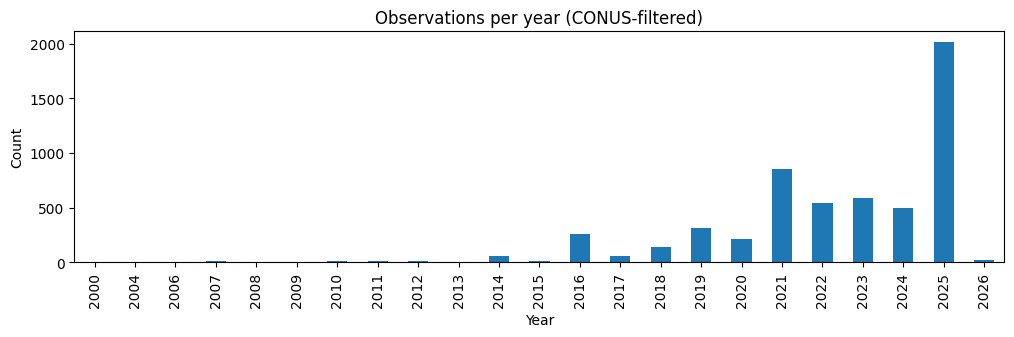

In [5]:
# Quick sanity checks
year_counts = df.groupby('year').size().sort_index()
display(year_counts.tail(15))

# Optional: plot per-year counts
ax = year_counts.plot(kind='bar', figsize=(12, 3), title='Observations per year (CONUS-filtered)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')


In [6]:
# ...existing code...
def cumulative_map(df: pd.DataFrame, year: int):
    d = df[df['year'] <= year].copy()
    n = len(d)
    title = f"Amanita phalloides — cumulative iNaturalist observations through {year} (CONUS; n={n:,})"

    hover_data = {'lat': False, 'lon': False, 'year': True}
    if 'url' in d.columns:
        hover_data['url'] = True

    # Color by year so newer points read as "hotter"
    fig = px.scatter_geo(
        d,
        lat='lat',
        lon='lon',
        color='year',
        color_continuous_scale='YlOrRd',
        range_color=[int(df['year'].min()), int(df['year'].max())],
        opacity=POINT_OPACITY,
        title=title,
        hover_name='common_name' if 'common_name' in d.columns else None,
        hover_data=hover_data,
    )

    # nicer markers: small, slightly outlined for contrast
    fig.update_traces(
        marker=dict(size=6, line=dict(width=0.6, color='rgba(0,0,0,0.15)'))
    )

    # US background + projection
    fig.update_geos(
        scope='usa',
        showland=True,
        landcolor='#f7f7f7',
        lakecolor='white',
        showcountries=True,
        showsubunits=True,
        subunitcolor='white',
        projection_type='albers usa',
    )

    # layout polish
    fig.update_layout(
        margin=dict(l=0, r=0, t=60, b=0),
        template='plotly_white',
        coloraxis_showscale=False,  # hide colorbar for cleaner frames
    )

    # big year annotation + small count caption (semi-opaque background for readability)
    fig.add_annotation(
        x=0.02, y=0.95, xref='paper', yref='paper',
        text=f"<b>{year}</b>",
        showarrow=False,
        font=dict(size=36, color='black'),
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='rgba(0,0,0,0.05)',
        borderpad=6,
    )
    fig.add_annotation(
        x=0.02, y=0.88, xref='paper', yref='paper',
        text=f"Observations (CONUS): {n:,}",
        showarrow=False,
        font=dict(size=12, color='black'),
        bgcolor='rgba(255,255,255,0.6)',
    )

    return fig
# ...existing code...


In [7]:
# Preview a representative year
test_year = int(df['year'].quantile(0.75))
fig = cumulative_map(df, test_year)
fig.show()


In [8]:
# ...existing code...
# Export frames (one per year) — use larger PNGs for higher-quality GIF
years = list(range(int(df['year'].min()), int(df['year'].max()) + 1))
print('Writing frames for years:', years[0], '→', years[-1])

for y in years:
    fig = cumulative_map(df, y)
    if MAKE_HTML:
        fig.write_html(OUTDIR / f"cum_{y}.html")
    if MAKE_PNG:
        # larger dimensions improve final GIF quality (requires kaleido)
        fig.write_image(OUTDIR / f"cum_{y}.png", width=1400, height=900, scale=2)

print('Done. Frames in:', OUTDIR.resolve())
# ...existing code...


Writing frames for years: 2000 → 2026
Done. Frames in: /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/frames


In [9]:
# Optional: build an animated GIF (requires PNG frames)
if MAKE_GIF:
    import imageio.v2 as imageio
    pngs = sorted(OUTDIR.glob('cum_*.png'))
    if not pngs:
        raise RuntimeError('No PNG frames found. Set MAKE_PNG=True, re-run exports, then re-run this cell.')
    gif_path = OUTDIR / 'amanita_phalloides_conus_cumulative.gif'
    frames = [imageio.imread(p) for p in pngs]
    imageio.mimsave(gif_path, frames, fps=3)
    print('Wrote:', gif_path.resolve())
else:
    print('MAKE_GIF is False; skipping GIF creation.')


Wrote: /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/frames/amanita_phalloides_conus_cumulative.gif
